# U2 — Aggregate Router Analysis (RQ2)

**Research question (RQ2):** Is computation allocated differently across modalities? Do tokens from different modalities specialise at distinct recursion depths?

**Outputs:**
- `results/milestone2/router/per_modality_depth.json` — per-modality stats + bootstrap CIs (consumed by U1 FLOPs and by U4 headline figure)
- `results/milestone2/router/per_modality_depth_bar.pdf` — bar plot with CI error bars
- `results/milestone2/router/depth_distribution_hist.pdf` — per-depth fraction histograms
- `results/milestone2/router/spatial_maps_{modality}.pdf` — mean+std spatial maps per image modality
- `results/milestone2/router/context_conditioning_grid.pdf` — mean normalised depth per (target, context) cell

**Convention:** all cross-checkpoint plots use normalised depth `d_norm = (d-1)/(Nr-1) ∈ [0,1]`.

In [32]:
import os
os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')

import json
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex, ListedColormap, BoundaryNorm
import torch

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_DIR)

try:
    from torch.distributed.tensor import DTensor
except ImportError:
    class DTensor:
        pass
import transformers.modeling_utils
transformers.modeling_utils.DTensor = DTensor

from util.env import load_dotenv
load_dotenv()
from paths import HF_CACHE_DIR
os.environ.setdefault('HF_HOME', HF_CACHE_DIR)

from omegaconf import open_dict
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from transformers import AutoTokenizer

from lm_dataset.multimodal_vocab_shared_caption_scene_desc import MODALITIES
from model.util import load_model_from_config, load_checkpoint
from model.sharing_strategy import SHARING_STRATEGY
from util.config import preprocess_config

from scripts._routing_lib import Modality, collect_routing, load_sample, SAMPLES_U2_U3

OUT_DIR = PROJECT_DIR / 'results' / 'milestone2' / 'router'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_TEST = PROJECT_DIR / 'data' / 'clevr_dataset' / 'test'
PATCH_GRID = 16
N_SAMPLES    = 100   # main analysis
N_GEN_SAMPLES = 30   # gen-vs-TF regime (slower)
N_BOOTSTRAP  = 1000
RNG_SEED     = 42

# Load preflight
preflight_path = PROJECT_DIR / 'results' / 'milestone2' / 'preflight.json'
if preflight_path.exists():
    preflight = json.load(open(preflight_path))
    print('Preflight checkpoints:', [k for k in preflight if isinstance(preflight[k], dict) and 'Nr' in preflight[k]])
else:
    preflight = {}
    print('WARNING: preflight.json not found. Run U0 first.')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# Muted pastel colour palette — consistent across all plots in this notebook
PALETTE = {
    'tok_rgb@256':   '#7BAFD4',
    'tok_depth@256': '#E87878',
    'tok_normal@256':'#7DC47D',
    'caption':       '#A87DC8',
    'scene_desc':    '#F0A860',
}
GEN_TF_COLORS = ('#7BAFD4', '#E87878')  # teacher-forced, generated

# Depth palette: temperature gradient (cool→hot), fixed per absolute depth level so
# d=1/2/3 are identical across checkpoints regardless of Nr.
_PLASMA = mpl.colormaps["Oranges"]  # reversed viridis for better visibility on white background
MAX_RECUR = 4  # maximum Nr across all checkpoints in this notebook
DEPTH_COLORS = [
    to_hex(_PLASMA(i / max(1, MAX_RECUR - 1))) for i in range(MAX_RECUR)
]


def make_depth_palette(NUM_RECUR: int):
    colors = DEPTH_COLORS[:NUM_RECUR]
    DEPTH_CMAP = ListedColormap(colors)
    DEPTH_NORM = BoundaryNorm(
        boundaries=[i - 0.5 for i in range(NUM_RECUR + 1)], ncolors=NUM_RECUR
    )
    return colors, DEPTH_CMAP, DEPTH_NORM


Preflight checkpoints: ['mor_5000_3r', 'mor_5000_4r', 'baseline_vanilla', 'random_router_5000']
Device: cuda


## Checkpoint configurations

Both published multimodal checkpoints. Add new ones as they land.

In [3]:
# Final M2 checkpoints (baseline included; produces no routing data but loads OK)
CHECKPOINTS = [
    {
        'label': 'mor_5000_3r',
        'config': 'infer/mor_5000_multimodality_3r',
        'display': 'MoR tok-choice Nr=3 (5k)',
        'nr': 3,
        'active_modalities': ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc'],
    },
    {
        'label': 'mor_5000_4r',
        'config': 'infer/mor_5000_multimodality_4r',
        'display': 'MoR tok-choice Nr=4 (5k)',
        'nr': 4,
        'active_modalities': ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc'],
    },
    {
        'label': 'random_router_5000',
        'config': 'infer/random_router_5000_multimodality',
        'display': 'Random router Nr=3 (5k)',
        'nr': 3,
        'active_modalities': ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc'],
    },
]

# Override active_modalities from preflight if available
for ckpt in CHECKPOINTS:
    if ckpt['label'] in preflight and 'active_modalities' in preflight[ckpt['label']]:
        ckpt['active_modalities'] = preflight[ckpt['label']]['active_modalities']
        print(f"  {ckpt['label']}: active_modalities from preflight = {ckpt['active_modalities']}")

SAMPLES = SAMPLES_U2_U3[:N_SAMPLES]
print(f'Using {len(SAMPLES)} samples')

  mor_5000_3r: active_modalities from preflight = ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc']
  mor_5000_4r: active_modalities from preflight = ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc']
  random_router_5000: active_modalities from preflight = ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc']
Using 100 samples


In [4]:
def build_cfg(cfg_name: str):
    if GlobalHydra().is_initialized():
        GlobalHydra().clear()
    with initialize_config_dir(config_dir=str(PROJECT_DIR / 'conf'), version_base=None):
        cfg = compose(config_name=cfg_name)
    with open_dict(cfg):
        cfg.wandb = False
        cfg.wandb_entity = ''
        cfg.wandb_project = 'u2'
        cfg.wandb_run_name = 'u2'
        cfg.resume_from_checkpoint = False
    return preprocess_config(cfg)


def load_model(cfg_name: str):
    cfg = build_cfg(cfg_name)
    m = load_model_from_config(cfg)
    if cfg.recursive.get('enable'):
        m, _ = SHARING_STRATEGY[cfg.model](cfg, m)
    if cfg.get('mor') and cfg.mor.get('enable'):
        if cfg.mor.type == 'token':
            m.transform_layer_to_mor_token(cfg)
        elif cfg.mor.type == 'expert':
            m.transform_layer_to_mor_expert(cfg)
    m = load_checkpoint(m, cfg.infer.checkpoint)
    m.to(device).eval()
    return cfg, m


def d_norm(d: float, nr: int) -> float:
    """Normalise depth to [0,1] for cross-checkpoint comparison."""
    if nr <= 1:
        return 0.0
    return (d - 1) / (nr - 1)


def bootstrap_ci(arr: np.ndarray, n: int = N_BOOTSTRAP) -> dict:
    rng = np.random.default_rng(RNG_SEED)
    idx = rng.integers(0, len(arr), (n, len(arr)))
    boot = arr[idx].mean(axis=1)
    return {
        'mean': float(arr.mean()),
        'lo': float(np.percentile(boot, 2.5)),
        'hi': float(np.percentile(boot, 97.5)),
    }


mod = Modality(AutoTokenizer.from_pretrained('gpt2'), text_max_len=64)
print('Helpers ready.')

Helpers ready.


## Per-modality depth distribution (teacher-forced)

For each checkpoint: build full GT sequences using all active modalities in random order (matching training), collect routing, segment per-modality, aggregate mean depth and depth histogram with bootstrap CIs.

In [5]:
all_checkpoint_stats = {}  # label → {modality → {mean, std, hist, ci}}

for ckpt in CHECKPOINTS:
    label    = ckpt['label']
    cfg_name = ckpt['config']
    nr       = ckpt['nr']
    active   = ckpt['active_modalities']
    print(f'\n=== {ckpt["display"]} ===')

    try:
        cfg, model = load_model(cfg_name)
    except Exception as e:
        print(f'  SKIP: {e}')
        all_checkpoint_stats[label] = {'error': str(e)}
        continue

    # bag[modality] = list of per-token depth values (concatenated across samples)
    bag = {m: [] for m in active}
    rng = np.random.default_rng(RNG_SEED)

    for i, (sid, aug_idx) in enumerate(SAMPLES):
        s = load_sample(DATA_TEST, sid, aug_idx)
        # Build sequence with all active modalities in random order (matching training)
        order = rng.permutation(active).tolist()
        chunks = []
        for m in order:
            if m in ('tok_rgb@256', 'tok_depth@256', 'tok_normal@256'):
                short = m.split('@')[0].replace('tok_', '')  # 'rgb', 'depth', 'normal'
                arr = s.get(short)
                if arr is None:
                    continue
                chunks.append(mod.chunk_tokens(m, arr, aug_idx=0, close=True))
            elif m == 'caption':
                cap = s.get('caption')
                if cap is None:
                    continue
                chunks.append(mod.chunk_text(m, cap))
            elif m == 'scene_desc':
                sd = s.get('scene_desc')
                if sd is None:
                    continue
                chunks.append(mod.chunk_text(m, sd))
        if not chunks:
            continue
        seq = torch.cat(chunks)

        try:
            d = collect_routing(model, None, seq, device)  # (L, T) depths in [1, Nr]
        except Exception as e:
            print(f'  WARN {sid}: {e}')
            continue

        for st, en, m in mod.segment(seq):
            if m in bag:
                bag[m].extend(d[:, st:en].float().mean(dim=0).tolist())  # mean across layers

        if (i + 1) % 20 == 0:
            print(f'  {i+1}/{len(SAMPLES)}')

    stats = {}
    for m, depths in bag.items():
        if not depths:
            stats[m] = {'note': 'no samples'}
            continue
        arr = np.array(depths)
        ci = bootstrap_ci(arr)
        ci_norm = {k: d_norm(v, nr) if isinstance(v, float) else v for k, v in ci.items()}
        hist = {str(k): float((arr.round() == k).mean()) for k in range(1, nr + 1)}
        stats[m] = {
            'n_tokens': int(arr.size),
            'mean': ci['mean'], 'lo': ci['lo'], 'hi': ci['hi'],
            'mean_norm': ci_norm['mean'], 'lo_norm': ci_norm['lo'], 'hi_norm': ci_norm['hi'],
            'std': float(arr.std()),
            'depth_hist': hist,
            'register_frac': hist.get(str(nr), 0.0),  # fraction at max depth
        }
        print(f'  {m}: mean_depth={ci["mean"]:.3f} [{ci["lo"]:.3f},{ci["hi"]:.3f}], '
              f'd_norm={ci_norm["mean"]:.3f}, register_frac={hist.get(str(nr),0):.3f}')

    all_checkpoint_stats[label] = {'nr': nr, 'display': ckpt['display'], 'modality_stats': stats}
    del model; torch.cuda.empty_cache()

print('\nPer-modality collection done.')


=== MoR tok-choice Nr=3 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_3r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 29502.72it/s]

  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-modalities/snapshots/837cbe67df057b50040122bf721d1b03cc66bfaa


  20/100
  40/100
  60/100
  80/100
  100/100
  tok_rgb@256: mean_depth=1.612 [1.604,1.621], d_norm=0.306, register_frac=0.139
  tok_depth@256: mean_depth=1.597 [1.586,1.608], d_norm=0.298, register_frac=0.246
  tok_normal@256: mean_depth=2.618 [2.609,2.627], d_norm=0.809, register_frac=0.789
  caption: mean_depth=2.247 [2.221,2.274], d_norm=0.624, register_frac=0.558
  scene_desc: mean_depth=2.730 [2.718,2.742], d_norm=0.865, register_frac=0.736

=== MoR tok-choice Nr=4 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_4r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/s

Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 5524.64it/s]


  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-4-recursions-steps/snapshots/2b8fe44c6de65c309cd5d8f56035b93546198f77
  20/100
  40/100
  60/100
  80/100
  100/100
  tok_rgb@256: mean_depth=1.815 [1.802,1.828], d_norm=0.272, register_frac=0.167
  tok_depth@256: mean_depth=2.169 [2.155,2.183], d_norm=0.390, register_frac=0.231
  tok_normal@256: mean_depth=2.211 [2.197,2.225], d_norm=0.404, register_frac=0.271
  caption: mean_depth=3.568 [3.541,3.594], d_norm=0.856, register_frac=0.745
  scene_desc: mean_depth=3.946 [3.940,3.952], d_norm=0.982, register_frac=0.946

=== Random router Nr=3 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setti

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 28378.24it/s]

  Cached at: /home/hugues/.cache/huggingface/hub/models--romanevrwld--Random-Router-Baseline-5000-Multimodality/snapshots/411933d74ab13064bd141780ba1c8cacc7598a96


  20/100
  40/100
  60/100
  80/100
  100/100
  tok_rgb@256: mean_depth=1.995 [1.985,2.005], d_norm=0.498, register_frac=0.333
  tok_depth@256: mean_depth=1.999 [1.989,2.009], d_norm=0.500, register_frac=0.332
  tok_normal@256: mean_depth=1.995 [1.985,2.005], d_norm=0.497, register_frac=0.330
  caption: mean_depth=1.993 [1.967,2.018], d_norm=0.496, register_frac=0.336
  scene_desc: mean_depth=1.984 [1.963,2.005], d_norm=0.492, register_frac=0.324

Per-modality collection done.


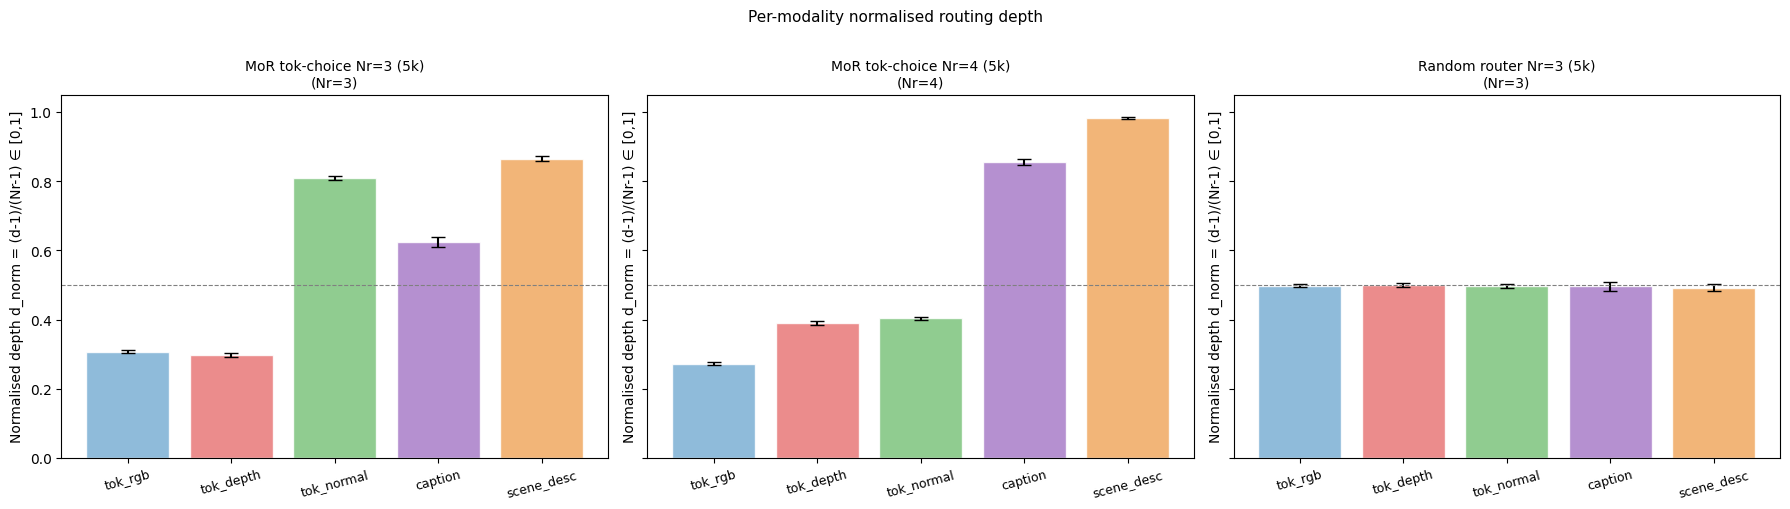

Saved per_modality_depth_bar.pdf


In [6]:
# Bar plot: mean normalised depth per modality per checkpoint, with bootstrap CI error bars
n_ckpts = len([l for l in all_checkpoint_stats if 'modality_stats' in all_checkpoint_stats[l]])
fig, axes = plt.subplots(1, max(n_ckpts, 1), figsize=(6 * max(n_ckpts, 1), 5), sharey=True)
if n_ckpts == 1:
    axes = [axes]

ax_idx = 0
for label, data in all_checkpoint_stats.items():
    if 'modality_stats' not in data:
        continue
    ax = axes[ax_idx]; ax_idx += 1
    stats = data['modality_stats']
    nr = data['nr']
    mods = [m for m in stats if 'mean_norm' in stats[m]]
    means = [stats[m]['mean_norm'] for m in mods]
    errs_lo = [stats[m]['mean_norm'] - stats[m]['lo_norm'] for m in mods]
    errs_hi = [stats[m]['hi_norm'] - stats[m]['mean_norm'] for m in mods]
    colors = [PALETTE.get(m, '#7f7f7f') for m in mods]
    x = np.arange(len(mods))
    ax.bar(x, means, yerr=[errs_lo, errs_hi], capsize=5,
           color=colors, edgecolor='white', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([m.replace('@256','') for m in mods], rotation=15, fontsize=9)
    ax.set_title(f'{data["display"]}\n(Nr={nr})', fontsize=10)
    ax.set_ylabel('Normalised depth d_norm = (d-1)/(Nr-1) ∈ [0,1]')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color='gray', lw=0.8, ls='--', label='midpoint')

plt.suptitle('Per-modality normalised routing depth',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'per_modality_depth_bar.pdf', bbox_inches='tight')
plt.show()
print('Saved per_modality_depth_bar.pdf')

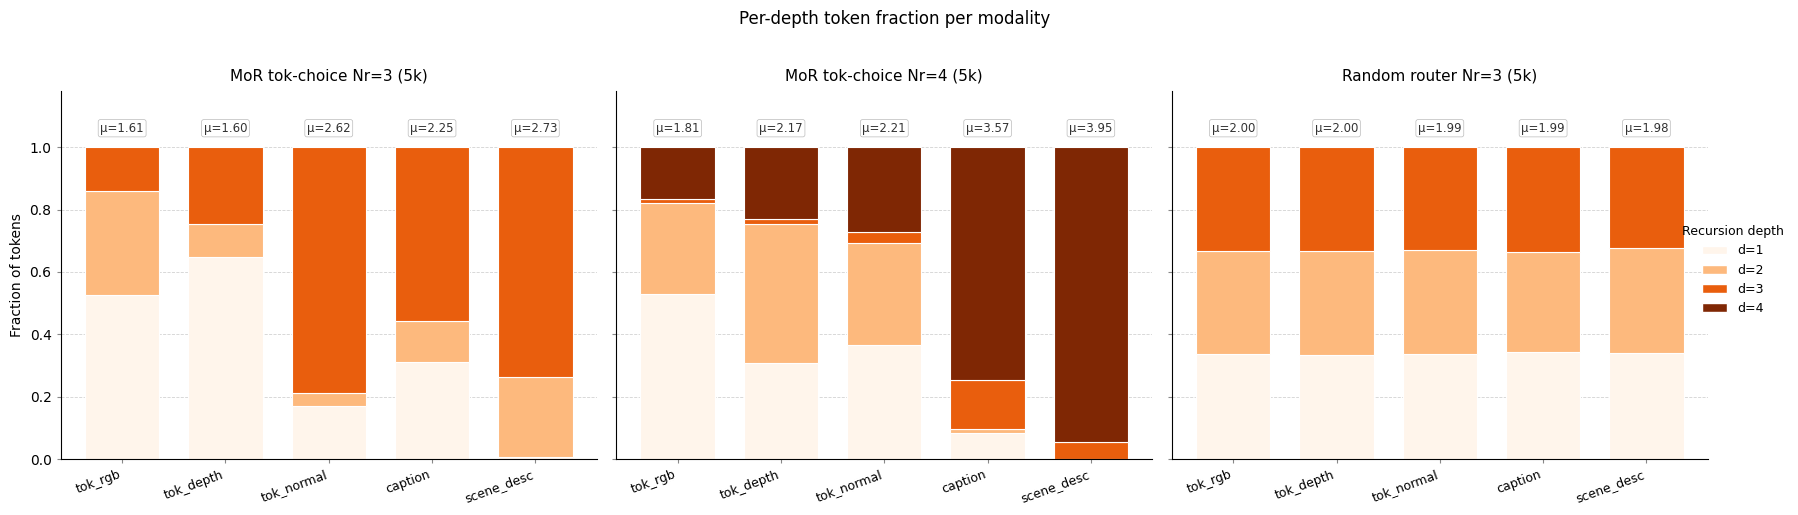

Saved depth_distribution_hist.pdf


In [33]:
# Depth fraction histograms: stacked bar per modality per checkpoint
fig, axes = plt.subplots(1, max(n_ckpts, 1), figsize=(6 * max(n_ckpts, 1), 5), sharey=True)
if n_ckpts == 1:
    axes = [axes]

ax_idx = 0
for label, data in all_checkpoint_stats.items():
    if 'modality_stats' not in data:
        continue
    ax = axes[ax_idx]; ax_idx += 1
    stats = data['modality_stats']
    nr = data['nr']
    mods = [m for m in stats if 'depth_hist' in stats[m]]
    x = np.arange(len(mods))
    depth_colors, _, _ = make_depth_palette(nr)

    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.35, color='gray', linewidth=0.6)

    bot = np.zeros(len(mods))
    for k in range(1, nr + 1):
        fracs = [stats[m]['depth_hist'].get(str(k), 0.0) for m in mods]
        ax.bar(
            x, fracs, bottom=bot,
            color=depth_colors[k - 1], label=f'd={k}',
            width=0.72, edgecolor='white', linewidth=0.8,
        )
        bot += np.array(fracs)

    # μ labels just above each bar, in a small grey pill
    for i, m in enumerate(mods):
        mu = stats[m]['mean']
        ax.text(
            i, 1.04, f'μ={mu:.2f}',
            ha='center', va='bottom', fontsize=8.5,
            color='#333',
            bbox=dict(boxstyle='round,pad=0.18', fc='white', ec='#bbb', lw=0.5),
        )

    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('@256', '') for m in mods], rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.18)
    ax.set_yticks(np.linspace(0, 1, 6))
    if ax_idx == 1:
        ax.set_ylabel('Fraction of tokens', fontsize=10)
    ax.set_title(data['display'], fontsize=11, pad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', length=3, color='#888')

# Single shared legend on the right (outside the last axis), with all depth bins
handles, labels = axes[-1].get_legend_handles_labels()
# Pad legend with the global MAX_RECUR depths so the legend is identical across runs
all_depth_handles = [
    plt.Rectangle((0, 0), 1, 1, fc=DEPTH_COLORS[k], ec='white')
    for k in range(MAX_RECUR)
]
all_depth_labels = [f'd={k+1}' for k in range(MAX_RECUR)]
fig.legend(
    all_depth_handles, all_depth_labels,
    loc='center right', bbox_to_anchor=(1.0, 0.5),
    frameon=False, title='Recursion depth', fontsize=9, title_fontsize=9,
)

plt.suptitle('Per-depth token fraction per modality', fontsize=12, y=1.02)
plt.tight_layout(rect=[0, 0, 0.96, 1.0])
plt.savefig(OUT_DIR / 'depth_distribution_hist.pdf', bbox_inches='tight')
plt.show()
print('Saved depth_distribution_hist.pdf')


## Spatial routing maps (image modalities)

Average mean-across-MoR-layers depth map across N_SAMPLES images.  
Companion per-position std map (across samples). High std → content-driven routing.

In [34]:
IMAGE_MODS = ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256']
IMAGE_MOD_SHORT = {'tok_rgb@256': 'rgb', 'tok_depth@256': 'depth', 'tok_normal@256': 'normal'}

for ckpt in CHECKPOINTS:
    label    = ckpt['label']
    cfg_name = ckpt['config']
    nr       = ckpt['nr']
    active   = ckpt['active_modalities']
    active_img = [m for m in IMAGE_MODS if m in active]
    if not active_img:
        continue
    print(f'\n=== Spatial maps: {ckpt["display"]} ===')

    try:
        cfg, model = load_model(cfg_name)
    except Exception as e:
        print(f'  SKIP: {e}')
        continue

    maps = {m: [] for m in active_img}  # list of (16, 16) mean-depth maps

    for sid, aug_idx in SAMPLES:
        s = load_sample(DATA_TEST, sid, aug_idx)
        for m in active_img:
            short = IMAGE_MOD_SHORT[m]
            arr = s.get(short)
            if arr is None:
                continue
            try:
                chunk = mod.chunk_tokens(m, arr, aug_idx=0, close=True)
                d = collect_routing(model, None, chunk, device)  # (L, T)
                segs = mod.segment(chunk)
                st, en, _ = next(((a, b, mm) for a, b, mm in segs if mm == m),
                                 (None, None, None))
                if st is not None:
                    body = d[:, st:en].float().mean(dim=0).numpy()  # (256,)
                    maps[m].append(body.reshape(PATCH_GRID, PATCH_GRID))
            except Exception as e:
                print(f'  WARN {sid} {m}: {e}')

    for m in active_img:
        if not maps[m]:
            continue
        stack = np.stack(maps[m])  # (N, 16, 16)
        mean_map = stack.mean(axis=0)
        std_map  = stack.std(axis=0)

        fig, axes = plt.subplots(1, 2, figsize=(9, 4))
        im0 = axes[0].imshow(mean_map, cmap='Blues', vmin=1, vmax=nr)
        axes[0].set_title(f'Mean depth (μ={mean_map.mean():.2f})', fontsize=11)
        axes[0].axis('off'); fig.colorbar(im0, ax=axes[0], fraction=0.046)

        im1 = axes[1].imshow(std_map, cmap='RdPu', vmin=0)
        axes[1].set_title(f'Per-position std (mean={std_map.mean():.3f})', fontsize=11)
        axes[1].axis('off'); fig.colorbar(im1, ax=axes[1], fraction=0.046)

        plt.suptitle(f'{ckpt["display"]} — {m}\n'
                     f'N={len(maps[m])} samples', fontsize=10)
        plt.tight_layout()
        fname = f'spatial_maps_{m.replace("@","_at_").replace("/","-")}_{label}.pdf'
        plt.savefig(OUT_DIR / fname, bbox_inches='tight')
        plt.close()
        print(f'  Saved {fname}')

    del model; torch.cuda.empty_cache()



=== Spatial maps: MoR tok-choice Nr=3 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_3r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 33420.75it/s]


  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-modalities/snapshots/837cbe67df057b50040122bf721d1b03cc66bfaa
  Saved spatial_maps_tok_rgb_at_256_mor_5000_3r.pdf
  Saved spatial_maps_tok_depth_at_256_mor_5000_3r.pdf
  Saved spatial_maps_tok_normal_at_256_mor_5000_3r.pdf

=== Spatial maps: MoR tok-choice Nr=4 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_4r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scr

/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


...

  Saved spatial_maps_tok_rgb_at_256_mor_5000_4r.pdf
  Saved spatial_maps_tok_depth_at_256_mor_5000_4r.pdf
  Saved spatial_maps_tok_normal_at_256_mor_5000_4r.pdf

=== Spatial maps: Random router Nr=3 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : random_router_5000_multimodality_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 24216.54it/s]

  Cached at: /home/hugues/.cache/huggingface/hub/models--romanevrwld--Random-Router-Baseline-5000-Multimodality/snapshots/411933d74ab13064bd141780ba1c8cacc7598a96


  Saved spatial_maps_tok_rgb_at_256_random_router_5000.pdf
  Saved spatial_maps_tok_depth_at_256_random_router_5000.pdf
  Saved spatial_maps_tok_normal_at_256_random_router_5000.pdf


## Context-conditioning grid

Rows = target modality, columns = single-modality conditioning context ∈ {none, + each other active modality}.  
Cell value: mean normalised depth on target body, with bootstrap CI.


=== Context conditioning: MoR tok-choice Nr=3 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_3r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 29026.33it/s]


  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-modalities/snapshots/837cbe67df057b50040122bf721d1b03cc66bfaa


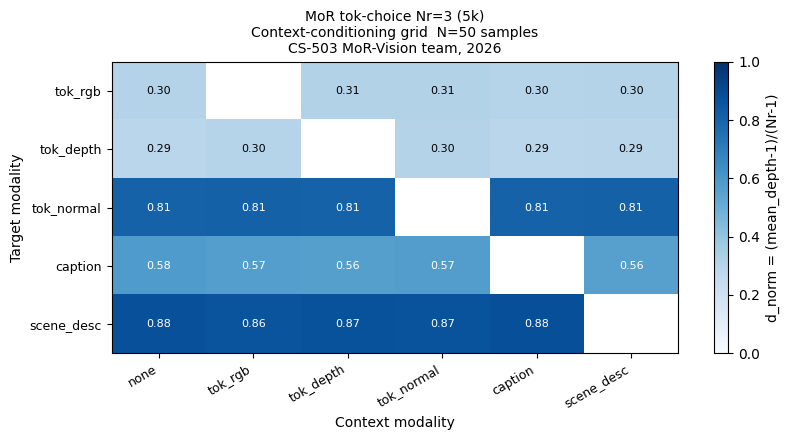

Saved context_conditioning_grid_mor_5000_3r.pdf

=== Context conditioning: MoR tok-choice Nr=4 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_4r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 30
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 4937.38it/s]

  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-4-recursions-steps/snapshots/2b8fe44c6de65c309cd5d8f56035b93546198f77


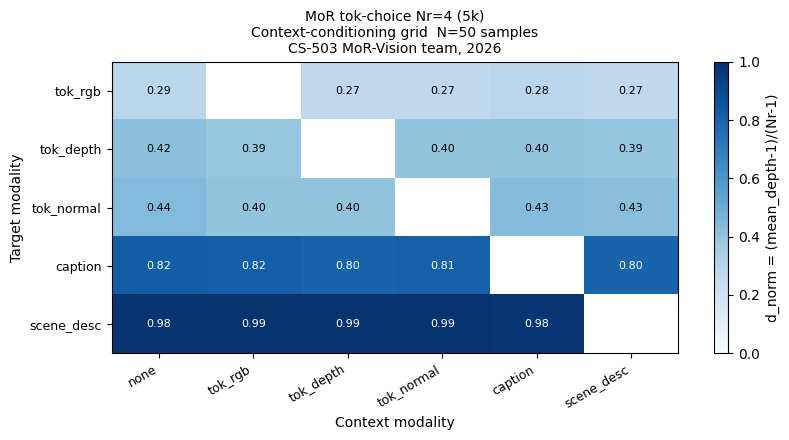

Saved context_conditioning_grid_mor_5000_4r.pdf

=== Context conditioning: Random router Nr=3 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : random_router_5000_multimodality_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 24995.85it/s]

  Cached at: /home/hugues/.cache/huggingface/hub/models--romanevrwld--Random-Router-Baseline-5000-Multimodality/snapshots/411933d74ab13064bd141780ba1c8cacc7598a96


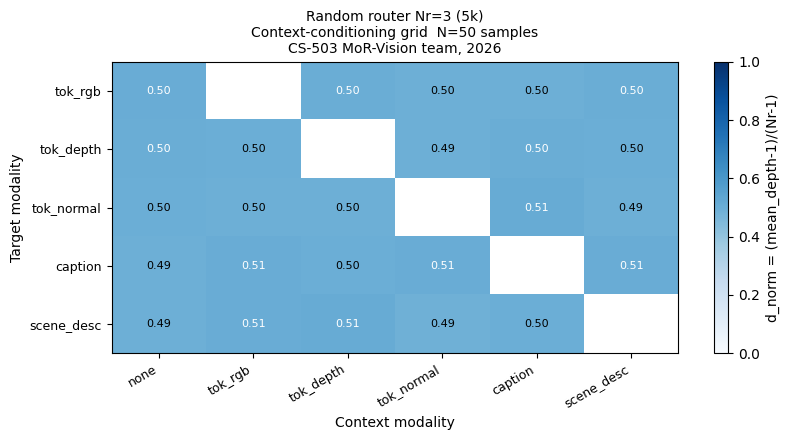

Saved context_conditioning_grid_random_router_5000.pdf


In [19]:
N_CONTEXT_SAMPLES = 50  # context conditioning is 2× slower (multiple forwards per sample)

for ckpt in CHECKPOINTS:
    label    = ckpt['label']
    cfg_name = ckpt['config']
    nr       = ckpt['nr']
    active   = ckpt['active_modalities']
    print(f'\n=== Context conditioning: {ckpt["display"]} ===')

    try:
        cfg, model = load_model(cfg_name)
    except Exception as e:
        print(f'  SKIP: {e}')
        continue

    # Grid: agg[target][ctx_label] = list of mean-depth values
    ctx_labels = ['none'] + active
    agg = {tgt: {cl: [] for cl in ctx_labels} for tgt in active}

    for sid, aug_idx in SAMPLES[:N_CONTEXT_SAMPLES]:
        s = load_sample(DATA_TEST, sid, aug_idx)

        def chunk_for(m):
            if m in ('tok_rgb@256', 'tok_depth@256', 'tok_normal@256'):
                short = m.split('@')[0].replace('tok_', '')
                arr = s.get(short)
                return mod.chunk_tokens(m, arr, aug_idx=0) if arr is not None else None
            elif m in ('caption', 'scene_desc'):
                text = s.get(m)
                return mod.chunk_text(m, text) if text else None
            return None

        for tgt in active:
            tgt_chunk = chunk_for(tgt)
            if tgt_chunk is None:
                continue
            for ctx_label in ctx_labels:
                if ctx_label == 'none':
                    ctx_chunk = None
                elif ctx_label == tgt:
                    continue  # skip self-conditioning (not meaningful)
                else:
                    ctx_chunk = chunk_for(ctx_label)
                    if ctx_chunk is None:
                        continue
                seq = torch.cat([ctx_chunk, tgt_chunk] if ctx_chunk is not None else [tgt_chunk])
                try:
                    d = collect_routing(model, None, seq, device)
                    segs = mod.segment(seq)
                    st, en, _ = next(((a, b, mm) for a, b, mm in segs if mm == tgt),
                                     (None, None, None))
                    if st is not None:
                        mean_d = float(d[:, st:en].float().mean())
                        agg[tgt][ctx_label].append(mean_d)
                except Exception as e:
                    pass  # skip silently

    # Plot grid
    tgt_mods = [t for t in active if any(agg[t][cl] for cl in ctx_labels)]
    ctx_used = [cl for cl in ctx_labels if any(agg[t].get(cl) for t in tgt_mods)]

    grid_means = np.full((len(tgt_mods), len(ctx_used)), np.nan)
    for ri, tgt in enumerate(tgt_mods):
        for ci, cl in enumerate(ctx_used):
            vals = agg[tgt][cl]
            if vals:
                grid_means[ri, ci] = d_norm(np.mean(vals), nr)

    fig, ax = plt.subplots(figsize=(max(6, len(ctx_used) * 1.4), max(4, len(tgt_mods) * 0.9)))
    im = ax.imshow(grid_means, cmap='Blues', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(ctx_used)))
    ax.set_xticklabels([c.replace('@256','') for c in ctx_used], rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(tgt_mods)))
    ax.set_yticklabels([t.replace('@256','') for t in tgt_mods], fontsize=9)
    ax.set_xlabel('Context modality')
    ax.set_ylabel('Target modality')
    for ri in range(len(tgt_mods)):
        for ci in range(len(ctx_used)):
            val = grid_means[ri, ci]
            if not np.isnan(val):
                ax.text(ci, ri, f'{val:.2f}', ha='center', va='center', fontsize=8,
                        color='white' if val > 0.5 else 'black')
    fig.colorbar(im, ax=ax, label='d_norm = (mean_depth-1)/(Nr-1)')
    ax.set_title(f'{ckpt["display"]}\nContext-conditioning grid  N={N_CONTEXT_SAMPLES} samples\n'
                 'CS-503 MoR-Vision team, 2026', fontsize=10)
    plt.tight_layout()
    fname = f'context_conditioning_grid_{label}.pdf'
    plt.savefig(OUT_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

    del model; torch.cuda.empty_cache()


## Generation vs teacher-forced routing regime

Re-run per-modality depth analysis with model-generated tokens (n=30 samples) instead of GT tokens.  
Report both side-by-side; the report cites the more conservative number.


=== Gen vs TF: MoR tok-choice Nr=3 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_3r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 29959.31it/s]

  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-modalities/snapshots/837cbe67df057b50040122bf721d1b03cc66bfaa


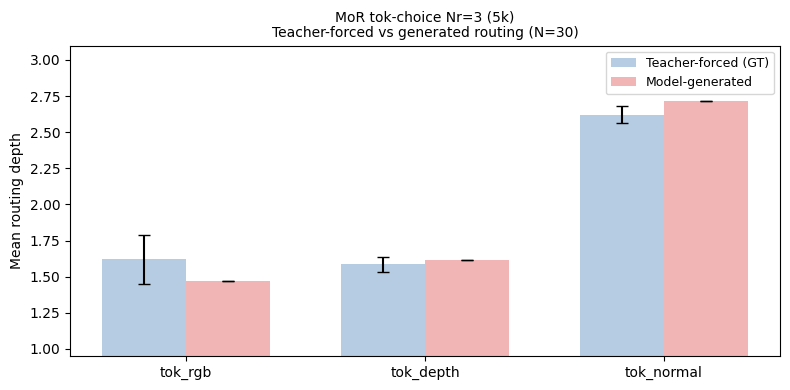

Saved gen_vs_tf_mor_5000_3r.pdf

=== Gen vs TF: MoR tok-choice Nr=4 (5k) ===
-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_4r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 30
 vocab_size: 242271


/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/util/config.py:95: UserWarning: stop_steps (19500) is not divisible by save_steps (5000)
  warnings.warn(warning)
/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/model/util.py:90: UserWarning: original max_position_embeddings of 2048 is changed to 1048
  warnings.warn(f"original max_position_embeddings of {config.max_position_embeddings} is changed to {cfg.max_length}")


Fetching 10 files: 100%|██████████| 10/10 [00:00<00:00, 44478.30it/s]


  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-4-recursions-steps/snapshots/2b8fe44c6de65c309cd5d8f56035b93546198f77


In [ ]:
from transformers import StoppingCriteria, StoppingCriteriaList
from lm_dataset.multimodal_vocab_shared_caption_scene_desc import PAD_ID

class _EoStop(StoppingCriteria):
    def __init__(self, eo_id):
        self.eo_id = eo_id
    def __call__(self, input_ids, scores, **kw):
        return bool((input_ids[:, -1] == self.eo_id).all())


gen_vs_tf_results = {}

for ckpt in CHECKPOINTS:
    label    = ckpt['label']
    cfg_name = ckpt['config']
    nr       = ckpt['nr']
    active   = ckpt['active_modalities']
    active_img = [m for m in IMAGE_MODS if m in active]
    if not active_img:
        continue
    print(f'\n=== Gen vs TF: {ckpt["display"]} ===')

    try:
        cfg, model = load_model(cfg_name)
    except Exception as e:
        print(f'  SKIP: {e}')
        continue

    rows = []
    for sid, aug_idx in SAMPLES[:N_GEN_SAMPLES]:
        s = load_sample(DATA_TEST, sid, aug_idx)
        for m in active_img:
            short = m.split('@')[0].replace('tok_', '')
            arr = s.get(short)
            if arr is None:
                continue
            info = MODALITIES[m]

            # Teacher-forced
            try:
                chunk_tf = mod.chunk_tokens(m, arr, aug_idx=0, close=True)
                d_tf = collect_routing(model, None, chunk_tf, device)
                segs = mod.segment(chunk_tf)
                st, en, _ = next(((a, b, mm) for a, b, mm in segs if mm == m), (None, None, None))
                tf_mean = float(d_tf[:, st:en].float().mean()) if st is not None else np.nan
            except:
                tf_mean = np.nan

            # Generated
            try:
                prompt = torch.tensor([info.bo_id]).unsqueeze(0).to(device)
                with torch.no_grad():
                    gen = model.generate(
                        input_ids=prompt,
                        attention_mask=torch.ones_like(prompt),
                        max_new_tokens=257,
                        use_cache=False,
                        stopping_criteria=StoppingCriteriaList([_EoStop(info.eo_id)]),
                        do_sample=False,
                        pad_token_id=PAD_ID,
                    )
                body = gen[0, 1:].cpu()
                body = body[(body != info.bo_id) & (body != info.eo_id) & (body != PAD_ID)]
                body_arr = (body - info.codebook_offset).numpy()[:PATCH_GRID**2]
                if body_arr.size < PATCH_GRID**2:
                    body_arr = np.pad(body_arr, (0, PATCH_GRID**2 - body_arr.size))
                chunk_gen = mod.chunk_tokens(m, body_arr, aug_idx=0, close=True)
                d_gen = collect_routing(model, None, chunk_gen, device)
                segs2 = mod.segment(chunk_gen)
                st2, en2, _ = next(((a, b, mm) for a, b, mm in segs2 if mm == m), (None, None, None))
                gen_mean = float(d_gen[:, st2:en2].float().mean()) if st2 is not None else np.nan
            except:
                gen_mean = np.nan

            rows.append({'sid': sid, 'modality': m, 'tf_mean': tf_mean, 'gen_mean': gen_mean})

    gen_vs_tf_results[label] = rows

    # Plot TF vs Gen side by side per modality
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(active_img))
    w = 0.35
    for offset, key, color, lbl in [(-w/2, 'tf_mean', GEN_TF_COLORS[0], 'Teacher-forced (GT)'),
                                      (+w/2, 'gen_mean', GEN_TF_COLORS[1], 'Model-generated')]:
        vals = [[r[key] for r in rows if r['modality'] == m and not np.isnan(r[key])] for m in active_img]
        means = [np.mean(v) if v else np.nan for v in vals]
        stds  = [np.std(v)  if v else 0.     for v in vals]
        ax.bar(x + offset, means, width=w, label=lbl, color=color, yerr=stds, capsize=4, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([m.replace('@256','') for m in active_img], fontsize=10)
    ax.set_ylim(0.95, nr + 0.1)
    ax.set_ylabel('Mean routing depth')
    ax.set_title(f'{ckpt["display"]}\nTeacher-forced vs generated routing (N={N_GEN_SAMPLES})', fontsize=10)
    ax.legend(fontsize=9)
    plt.tight_layout()
    fname = f'gen_vs_tf_{label}.pdf'
    plt.savefig(OUT_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')

    del model; torch.cuda.empty_cache()


In [ ]:
# Save per_modality_depth.json (consumed by U1 FLOPs and U4 headline scatter)
json_out = {}
for label, data in all_checkpoint_stats.items():
    if 'modality_stats' not in data:
        continue
    json_out[label] = {
        'display': data['display'],
        'nr': data['nr'],
        'per_modality_stats': data['modality_stats'],
    }

out_path = OUT_DIR / 'per_modality_depth.json'
with open(out_path, 'w') as f:
    json.dump(json_out, f, indent=2)
print(f'Saved {out_path}')

# Prose interpretation
print('\n=== Mechanistic interpretation ===')
for label, data in all_checkpoint_stats.items():
    if 'modality_stats' not in data:
        continue
    stats = data['modality_stats']
    ranked = sorted(
        [(m, stats[m]['mean']) for m in stats if 'mean' in stats[m]],
        key=lambda x: x[1], reverse=True
    )
    print(f'\n{data["display"]}:')
    print('  Modality depth ranking (high → low compute):')
    for m, v in ranked:
        ci = stats[m]
        print(f'    {m:25s}: d={v:.3f} [{ci["lo"]:.3f}, {ci["hi"]:.3f}]  d_norm={ci["mean_norm"]:.3f}')
    print('  Register-token fractions (d=Nr fraction):')
    for m, _ in ranked:
        print(f'    {m:25s}: {stats[m].get("register_frac", 0):.3f}')

Saved /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/results/milestone2/router/per_modality_depth.json

=== Mechanistic interpretation ===

MoR tok-choice Nr=3 (5k):
  Modality depth ranking (high → low compute):
    scene_desc               : d=2.730 [2.718, 2.742]  d_norm=0.865
    tok_normal@256           : d=2.618 [2.609, 2.627]  d_norm=0.809
    caption                  : d=2.247 [2.221, 2.274]  d_norm=0.624
    tok_rgb@256              : d=1.612 [1.604, 1.621]  d_norm=0.306
    tok_depth@256            : d=1.597 [1.586, 1.608]  d_norm=0.298
  Register-token fractions (d=Nr fraction):
    scene_desc               : 0.736
    tok_normal@256           : 0.789
    caption                  : 0.558
    tok_rgb@256              : 0.139
    tok_depth@256            : 0.246

MoR tok-choice Nr=4 (5k):
  Modality depth ranking (high → low compute):
    scene_desc               : d=3.946 [3.940, 3.952]  d_norm=0.982
    caption                  : d=3.568 [3.541, 